<a href="https://colab.research.google.com/github/nyouyou1113/YOLOv9-/blob/main/YOLOv9ShipDetection_Inland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## YOLOv9

###  Clone the YOLOv9 Repository

clone the official YOLOv9 repository from `WongKinYiu`.

In [ ]:
# 检查并删除已存在的 yolov9 文件夹
import shutil
import os
if os.path.exists('yolov9'):
    shutil.rmtree('yolov9')
    print('已删除旧的 yolov9 文件夹。')

# Clone the YOLOv9 repository
!git clone https://github.com/WongKinYiu/yolov9.git

# Change to the yolov9 directory
%cd yolov9

Cloning into 'yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 49.98 MiB/s, done.
Resolving deltas: 100% (330/330), done.
/content/yolov9


In [ ]:
# Install dependencies
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 139.9 MB/s eta 0:00:00


In [ ]:
# Download yolov9-c.pt weights
!wget -P . https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt

# Download gelan-c.pt weights (often used with yolov9-c)
!wget -P . https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt

print("YOLOv9-c.pt and gelan-c.pt weights have been downloaded.")

--2026-05-10 10:33:18--  https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/759338070/c8ca43f2-0d2d-4aa3-a074-426505bfbfb1?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-10T11%3A16%3A26Z&rscd=attachment%3B+filename%3Dyolov9-c.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-10T10%3A16%3A22Z&ske=2026-05-10T11%3A16%3A26Z&sks=b&skv=2018-11-09&sig=99t5smYHwmsnz%2BrwBvSOpKktinw71ogeYMnoQwluUc8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3ODQxMDk5OCwibmJmIjoxNzc4NDA5MTk4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNv

### Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### dataset和yaml加载


In [ ]:
# List directories in your Google Drive's MyDrive folder
!ls -F /content/drive/MyDrive

'Colab Notebooks'/   MEIWVD-v1.zip   YOLOv9_Graduation/   YOLOv9_Project/


In [ ]:
import os

# 1. 解压数据集 zip 文件到 yolov9 目录
zip_path = '/content/drive/MyDrive/YOLOv9_Project/meiwvd_final_dataset_v1.zip'
target_dir = '/content/yolov9/'

if os.path.exists(zip_path):
    print(f'正在解压数据集: {zip_path}')
    !unzip -q {zip_path} -d {target_dir}
    print('✅ 数据集解压完成。')
else:
    print(f'❌ 未找到数据集文件: {zip_path}')

# 2. 复制 YAML 配置文件
yaml_source = '/content/drive/MyDrive/YOLOv9_Graduation/Backup_20260415_1413/meiwvd_v9_cleaned.yaml'
yaml_dest = '/content/yolov9/meiwvd_v9_cleaned.yaml'

if os.path.exists(yaml_source):
    import shutil
    shutil.copy(yaml_source, yaml_dest)
    print(f'✅ YAML 配置文件已复制到: {yaml_dest}')
else:
    print(f'❌ 未找到 YAML 文件: {yaml_source}')

正在解压数据集: /content/drive/MyDrive/YOLOv9_Project/meiwvd_final_dataset_v1.zip
✅ 数据集解压完成。
✅ YAML 配置文件已复制到: /content/yolov9/meiwvd_v9_cleaned.yaml


In [ ]:
import os
import shutil

base_path = '/content/yolov9/'
target_folder = os.path.join(base_path, 'meiwvd_final_split')

# Create the target directory if it doesn't exist
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
    print(f'Created folder: {target_folder}')

# Move images and labels folders
for folder_name in ['images', 'labels']:
    src = os.path.join(base_path, folder_name)
    dst = os.path.join(target_folder, folder_name)

    if os.path.exists(src):
        if os.path.exists(dst):
            print(f'Warning: {dst} already exists. Skipping move for {folder_name}.')
        else:
            shutil.move(src, dst)
            print(f'Successfully moved {src} to {dst}')
    else:
        print(f'Error: Source folder {src} not found.')

Created folder: /content/yolov9/meiwvd_final_split
Successfully moved /content/yolov9/images to /content/yolov9/meiwvd_final_split/images
Successfully moved /content/yolov9/labels to /content/yolov9/meiwvd_final_split/labels


###  CUDA检测


In [ ]:
import torch
print(f"CUDA 可用性: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 设备: {torch.cuda.get_device_name(0)}")

CUDA 可用性: True
GPU 设备: NVIDIA L4


### 模型训练


#### yolov9-c


In [ ]:
# Patch train_dual.py
!sed -i "s/ckpt = torch.load(weights, map_location='cpu')/ckpt = torch.load(weights, map_location='cpu', weights_only=False)/" /content/yolov9/train_dual.py

# Patch models/experimental.py
!sed -i "s/ckpt = torch.load(attempt_download(w), map_location='cpu')/ckpt = torch.load(attempt_download(w), map_location='cpu', weights_only=False)/" /content/yolov9/models/experimental.py

# Patch utils/general.py
!sed -i "s/x = torch.load(f, map_location=torch.device('cpu'))/x = torch.load(f, map_location=torch.device('cpu'), weights_only=False)/" /content/yolov9/utils/general.py

print('✅ Successfully patched YOLOv9 files for weights loading compatibility.')

✅ Successfully patched YOLOv9 files for weights loading compatibility.


In [ ]:
# 安装 ultralytics 库
!pip install ultralytics

from ultralytics import YOLO

# 1. 清理可能存在的旧缓存文件
!find meiwvd_final_split/ -name "*.cache" -delete

# 2. 初始化 Ultralytics YOLOv9c 模型
# 这会自动下载或加载官方权重
model = YOLO('yolov9c.pt')

# 3. 开始训练
results = model.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov9c_ultralytics_training'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=tor

#### yolov8

##### yolov8-n

In [ ]:
# Install the Ultralytics package for YOLOv8
!pip install ultralytics

import ultralytics
from ultralytics import YOLO
import torch

# Clear setup check
ultralytics.checks()

print(f"YOLOv8 version: {ultralytics.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Optional: Download a standard YOLOv8 model for testing/comparison
model_v8 = YOLO('yolov8n.pt')  # load an official detection model
print("YOLOv8 nano weights downloaded for comparison.")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 45.0/235.7 GB disk)
YOLOv8 version: 8.4.48
CUDA available: True
YOLOv8 nano weights downloaded for comparison.


In [ ]:
# Train YOLOv8 on the meiwvd dataset
# Using the same data yaml and image size for comparison
from ultralytics import YOLO

# 显式重新加载模型以防止 KeyError: 'model'
model_v8 = YOLO('yolov8n.pt')

results = model_v8.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov8_meiwvd_baseline'
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_meiwvd_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

##### yolov8-m

In [ ]:
from ultralytics import YOLO

# Load and download the YOLOv8-medium (yolov8m) model
model_v8m = YOLO('yolov8m.pt')

print("YOLOv8-medium weights have been successfully cloned/downloaded.")

YOLOv8-medium weights have been successfully cloned/downloaded.


In [ ]:
from ultralytics import YOLO

# Initialize the YOLOv8m model for training
model_v8m = YOLO('yolov8m.pt')

# Start training on the meiwvd dataset
results_v8m = model_v8m.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov8m_meiwvd_baseline'
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_meiwvd_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

#### Ultralytics yolov9-c

In [ ]:
from ultralytics import YOLO

# Initialize YOLOv9-c model from Ultralytics
model_v9c_ultra = YOLO('yolov9c.pt')

print("Ultralytics YOLOv9-c model has been successfully initialized.")

Ultralytics YOLOv9-c model has been successfully initialized.


In [ ]:
# Train Ultralytics YOLOv9-c on the meiwvd dataset
results_v9c_ultra = model_v9c_ultra.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov9c_ultralytics_meiwvd'
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9c_ultralytics_meiwvd, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

#### yolov10

In [ ]:
from ultralytics import YOLO

# Download YOLOv10-medium weights
model_v10m = YOLO('yolov10m.pt')

print("YOLOv10-medium weights have been successfully downloaded.")

YOLOv10-medium weights have been successfully downloaded.


In [ ]:
# Train YOLOv10-medium on the meiwvd dataset
# Using consistent parameters for comparison with YOLOv8

results_v10m = model_v10m.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov10m_meiwvd_baseline'
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10m_meiwvd_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

#### 模型对比
16 batch size，60 epochs，640 image size
| 模型版本 | 参数量 (Params) | 计算量 (FLOPs) | mAP@50-95 | mAP@50 | Precession |Recall|
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| YOLOv8-n | 3.0M | 8.1G | 0.731 | 0.844 | 0.989 |0.839|
| YOLOv8-m | 25.8M | 78.7G | 0.779 |0.861 | 0.978 |0.863|
| YOLOv10-m | 15.3M | 58.9G | 0.771 |0.859 | 0.979 |0.856|
| YOLOv9-c | 25.3M | 102.3G | 0.777 | 0.861 | 0.991 |0.860|
| YOLOv9-c-simAM | 25.3M | 102.3G | 0.736 | 0.850 | 0.955 |0.851|
| YOLOv9-c-P2 | 19.1M | 126.6G | 0.773 | 0.862 | 0.984 |0.859|
| YOLOv9-c-EIoU | 25.3M | 102.3G | 0.777 | 0.863 | 0.993 |0.855|
|Data Augment|

### 优化

#### 数据增强

In [ ]:
import os
import shutil
import random
import cv2
import numpy as np

# Install albumentations quietly if not already installed
try:
    import albumentations as A
except ImportError:
    print("Albumentations not found. Installing...")
    !pip install -q albumentations
    import albumentations as A

# --- Configuration ---
SOURCE_DATA_ROOT = '/content/yolov9/meiwvd_final_split'
AUGMENTED_DATA_ROOT = '/content/yolov9/meiwvd_final_split_augmented'
BUOY_CLASS_ID = 0  # Assuming 'Buoy' is class 0 based on previous outputs. Please verify if your dataset uses a different ID.
NUM_AUGMENTATIONS_PER_IMAGE = 3 # Number of augmented samples to create for each buoy image

# --- Step 1: Copy Replica ---
print(f"1. Copying data from {SOURCE_DATA_ROOT} to {AUGMENTED_DATA_ROOT}...")
if os.path.exists(AUGMENTED_DATA_ROOT):
    shutil.rmtree(AUGMENTED_DATA_ROOT)
    print(f"Removed existing {AUGMENTED_DATA_ROOT}")
shutil.copytree(SOURCE_DATA_ROOT, AUGMENTED_DATA_ROOT)
print("✅ Data replica created.")

# --- Step 2: Define Data Augmentation Pipeline ---
# This pipeline applies various random transformations.
# bbox_params is set to 'yolo' format for bounding box transformations.
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5), # Random horizontal flip
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Adjust brightness and contrast
    A.Affine(
        scale=(0.9, 1.1), # Corresponds to scale_limit=0.1
        translate_percent={'x': (-0.0625, 0.0625), 'y': (-0.0625, 0.0625)}, # Corresponds to shift_limit=0.0625
        rotate=(-10, 10), # Corresponds to rotate_limit=10
        p=0.3,
        border_mode=cv2.BORDER_CONSTANT, # Corrected from 'mode'
        value=0 # Corrected from 'cval'
    ), # Shift, scale, and rotate images (using Affine as recommended)
    A.Blur(blur_limit=3, p=0.1), # Apply slight blur
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.1), # Add Gaussian noise
    A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.1), # Shift RGB channels
    A.RandomGamma(p=0.1) # Apply random gamma correction
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_area=0.0, min_visibility=0.0, clip=True))

# --- Step 3: Augment Images with 'buoy' Class ---
print(f"\n2. Performing data augmentation for images containing 'buoy' (class_id={BUOY_CLASS_ID})...")

# Iterate through typical dataset splits (train, val, test)
for split in ['train', 'val', 'test']:
    images_dir = os.path.join(AUGMENTED_DATA_ROOT, 'images', split)
    labels_dir = os.path.join(AUGMENTED_DATA_ROOT, 'labels', split)

    if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
        print(f"Skipping split '{split}': images or labels directory not found in the copied dataset.")
        continue

    print(f"Processing split: {split}")
    augmented_count = 0

    # Iterate through each label file in the current split
    for label_filename in os.listdir(labels_dir):
        if not label_filename.endswith('.txt'):
            continue

        base_filename = os.path.splitext(label_filename)[0]
        image_extensions = ['.jpg', '.jpeg', '.png'] # Common image extensions
        image_file_path = None

        # Find the corresponding image file
        for ext in image_extensions:
            temp_path = os.path.join(images_dir, base_filename + ext)
            if os.path.exists(temp_path):
                image_file_path = temp_path
                break

        if not image_file_path:
            continue # Skip if no image found for this label file

        label_file_path = os.path.join(labels_dir, label_filename)

        # Read existing labels and bounding boxes
        original_bboxes = []
        original_class_ids = []
        with open(label_file_path, 'r') as f:
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                class_id = int(parts[0])
                bbox = parts[1:] # [x_center, y_center, width, height] in normalized YOLO format
                original_bboxes.append(bbox)
                original_class_ids.append(class_id)

        # Check if the 'buoy' class is present in this image's labels
        if BUOY_CLASS_ID in original_class_ids:
            image = cv2.imread(image_file_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Albumentations expects RGB

            # Apply augmentation multiple times to create more samples
            for i in range(NUM_AUGMENTATIONS_PER_IMAGE):
                transformed = augmentation_pipeline(image=image, bboxes=original_bboxes, class_ids=original_class_ids)
                transformed_image = transformed['image']
                transformed_bboxes = transformed['bboxes']
                transformed_class_ids = transformed['class_ids']

                # Skip if all bounding boxes were removed or became invalid after augmentation
                if len(transformed_bboxes) == 0:
                    continue

                # Generate new unique filenames for augmented image and label
                aug_image_filename = f"{base_filename}_aug_{random.randint(0, 99999)}_{i}.jpg"
                aug_label_filename = f"{os.path.splitext(aug_image_filename)[0]}.txt"

                aug_image_path = os.path.join(images_dir, aug_image_filename)
                aug_label_path = os.path.join(labels_dir, aug_label_filename)

                # Save augmented image (convert back to BGR for OpenCV)
                cv2.imwrite(aug_image_path, cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))

                # Save augmented labels in YOLO format
                with open(aug_label_path, 'w') as f:
                    for bbox, class_id in zip(transformed_bboxes, transformed_class_ids):
                        # Ensure bbox values are within [0, 1] for YOLO format when writing
                        bbox_str = ' '.join(map(lambda x: f'{max(0.0, min(1.0, x)):.6f}', bbox))
                        f.write(f"{int(class_id)} {bbox_str}\n")

                augmented_count += 1

    print(f"Added {augmented_count} augmented images to {split} split in {AUGMENTED_DATA_ROOT}.")

print("\n✅ Data augmentation complete. The augmented dataset is in:")
print(AUGMENTED_DATA_ROOT)
print("You can now update your YAML configuration to point to this new dataset root for training, or specifically use it for 'buoy' class balancing.")

1. Copying data from /content/yolov9/meiwvd_final_split to /content/yolov9/meiwvd_final_split_augmented...
✅ Data replica created.

2. Performing data augmentation for images containing 'buoy' (class_id=0)...
Processing split: train


/tmp/ipykernel_7736/1658428508.py:35: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(
/tmp/ipykernel_7736/1658428508.py:44: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.1), # Add Gaussian noise


Added 2046 augmented images to train split in /content/yolov9/meiwvd_final_split_augmented.
Processing split: val
Added 588 augmented images to val split in /content/yolov9/meiwvd_final_split_augmented.
Processing split: test
Added 285 augmented images to test split in /content/yolov9/meiwvd_final_split_augmented.

✅ Data augmentation complete. The augmented dataset is in:
/content/yolov9/meiwvd_final_split_augmented
You can now update your YAML configuration to point to this new dataset root for training, or specifically use it for 'buoy' class balancing.


--- 验证增强后的数据集 ---

处理 split: train
  找到图片文件: 2746
  找到标签文件: 2746
✅ train split 中的图片和标签文件数量匹配，且都存在对应项。

--- 可视化 train split 中的一个随机增强图片 ---


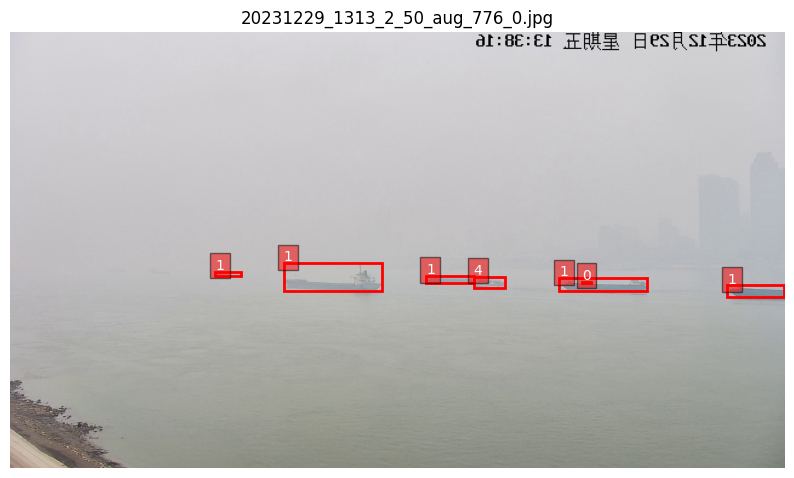


处理 split: val
  找到图片文件: 788
  找到标签文件: 788
✅ val split 中的图片和标签文件数量匹配，且都存在对应项。

--- 可视化 val split 中的一个随机增强图片 ---


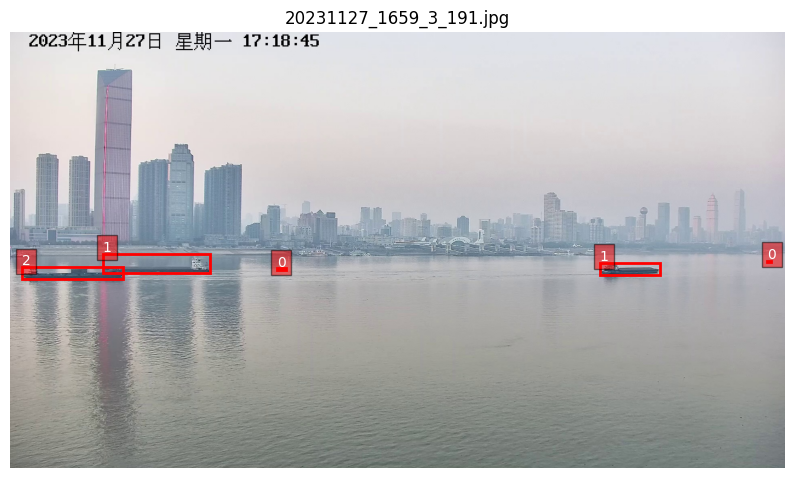


处理 split: test
  找到图片文件: 385
  找到标签文件: 385
✅ test split 中的图片和标签文件数量匹配，且都存在对应项。

--- 可视化 test split 中的一个随机增强图片 ---


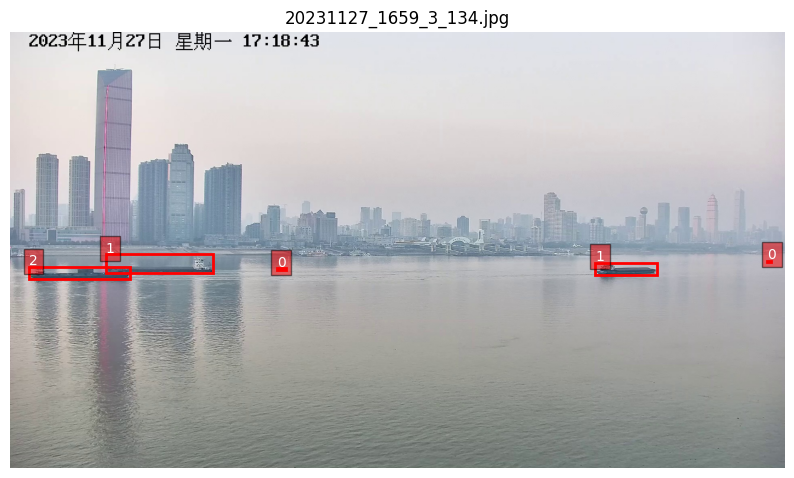


--- 验证完成 ---


In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

AUGMENTED_DATA_ROOT = '/content/yolov9/meiwvd_final_split_augmented'

image_extensions = ('.jpg', '.jpeg', '.png')

print("--- 验证增强后的数据集 ---")

for split in ['train', 'val', 'test']:
    images_dir = os.path.join(AUGMENTED_DATA_ROOT, 'images', split)
    labels_dir = os.path.join(AUGMENTED_DATA_ROOT, 'labels', split)

    if not os.path.exists(images_dir):
        print(f"❌ 警告: 图片目录不存在: {images_dir}")
        continue
    if not os.path.exists(labels_dir):
        print(f"❌ 警告: 标签目录不存在: {labels_dir}")
        continue

    print(f"\n处理 split: {split}")
    image_count = 0
    label_count = 0
    mismatched_files = 0
    sample_images = []

    # Check image files and their corresponding label files
    for img_filename in os.listdir(images_dir):
        if img_filename.lower().endswith(image_extensions):
            image_count += 1
            base_filename = os.path.splitext(img_filename)[0]
            label_filepath = os.path.join(labels_dir, base_filename + '.txt')

            if not os.path.exists(label_filepath):
                print(f"❌ 图片 {img_filename} 没有对应的标签文件。")
                mismatched_files += 1
            else:
                sample_images.append((os.path.join(images_dir, img_filename), label_filepath))

    # Check label files and their corresponding image files
    for label_filename in os.listdir(labels_dir):
        if label_filename.lower().endswith('.txt'):
            label_count += 1
            base_filename = os.path.splitext(label_filename)[0]
            found_image = False
            for ext in image_extensions:
                if os.path.exists(os.path.join(images_dir, base_filename + ext)):
                    found_image = True
                    break
            if not found_image:
                print(f"❌ 标签 {label_filename} 没有对应的图片文件。")
                mismatched_files += 1

    print(f"  找到图片文件: {image_count}")
    print(f"  找到标签文件: {label_count}")
    if mismatched_files == 0:
        print(f"✅ {split} split 中的图片和标签文件数量匹配，且都存在对应项。")
    else:
        print(f"⚠️ {split} split 中发现 {mismatched_files} 个不匹配的文件。")

    # Visualize a random augmented image if available
    if sample_images:
        print(f"\n--- 可视化 {split} split 中的一个随机增强图片 ---")
        img_path, label_path = random.choice(sample_images)

        img = cv2.imread(img_path)
        if img is None:
            print(f"❌ 无法读取图片: {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        fig, ax = plt.subplots(1, figsize=(10, 10))
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path))

        try:
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = list(map(float, line.strip().split()))
                    class_id = int(parts[0])
                    x_center, y_center, bbox_w, bbox_h = parts[1:]

                    # Convert YOLO format to pixel coordinates
                    x_min = int((x_center - bbox_w / 2) * w)
                    y_min = int((y_center - bbox_h / 2) * h)
                    box_width = int(bbox_w * w)
                    box_height = int(bbox_h * h)

                    rect = patches.Rectangle((x_min, y_min), box_width, box_height,
                                            linewidth=2, edgecolor='r', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x_min, y_min - 5, str(class_id), color='white', fontsize=10,
                            bbox=dict(facecolor='red', alpha=0.5))
        except FileNotFoundError:
            print(f"❌ 无法打开标签文件: {label_path}")
        plt.axis('off')
        plt.show()

print("\n--- 验证完成 ---")


In [ ]:
import yaml
import os

# 定义增强数据集的根目录
AUGMENTED_DATA_ROOT = '/content/yolov9/meiwvd_final_split_augmented'

# 定义类名和类别数量，这应该与原始数据集相同
nc = 5
names = ['Buoy', 'Cargo_ship', 'Container_ship', 'Passenger_ship', 'Speed_boat']

# 创建新的 YAML 配置内容
augmented_yaml_content = {
    'path': AUGMENTED_DATA_ROOT, # 设置数据集的根路径
    'train': 'images/train',      # 训练图片相对路径
    'val': 'images/val',          # 验证图片相对路径
    'test': 'images/test',        # 测试图片相对路径
    'nc': nc,
    'names': names
}

# 将 YAML 内容写入文件
augmented_yaml_path = '/content/yolov9/meiwvd_v9_augmented.yaml'
with open(augmented_yaml_path, 'w') as f:
    yaml.dump(augmented_yaml_content, f)

print(f"✅ 新的增强数据集 YAML 文件已创建: {augmented_yaml_path}")

✅ 新的增强数据集 YAML 文件已创建: /content/yolov9/meiwvd_v9_augmented.yaml


In [ ]:
# Install Ultralytics in case the environment reset
!pip install ultralytics

from ultralytics import YOLO

# 重新初始化 Ultralytics YOLOv9-c 模型
# 确保模型权重已下载 (yolov9c.pt)
model_v9c_ultra_augmented = YOLO('yolov9c.pt')

# 使用新的增强数据集 YAML 文件进行训练
results_v9c_ultra_augmented = model_v9c_ultra_augmented.train(
    data='/content/yolov9/meiwvd_v9_augmented.yaml', # 使用增强后的数据集配置
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov9c_ultralytics_meiwvd_augmented' # 命名以便区分训练结果
)

print("✅ 使用增强数据集的 Ultralytics YOLOv9-c 训练已启动。")
print("结果将保存到: runs/detect/yolov9c_ultralytics_meiwvd_augmented")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_augmented.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9c_ultralytics_meiwvd_augmented, nbs=64, nms=False, opset=None, optimize=False, optimiz

#### 改变损失函数计算方式

##### CIoU

In [ ]:
from ultralytics import YOLO

# Re-initialize the Ultralytics YOLOv9-c model if it's not already in scope
# Assuming yolov9c.pt is available in the current directory.
model_v9c_ultra_tuned = YOLO('yolov9c.pt')

# Train Ultralytics YOLOv9-c with modified loss parameters
# - 增加 'box' 损失权重，以更强调边界框的精确回归，这对于小目标的精确本地化至关重要。
#   默认值为 7.5，我们将其增加到 15.0。
# - 明确将 'iou' 指标设置为 'ciou' (Complete IoU)，它在边界框回归性能方面通常表现良好。
#   您也可以尝试 'giou' 等其他选项。
results_v9c_ultra_tuned_loss = model_v9c_ultra_tuned.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    # --- 修改后的损失参数 ---
    box=15.0,  # 增加 box 损失权重，以提高小目标的定位精度
    # 'iou' 参数应为浮点数（例如 0.5），表示 IoU 阈值，而非损失函数类型。
    # 如果要更改 IoU 损失函数（如 CIoU），则需要修改模型的 .yaml 文件或超参数文件。
    # --------------------------
    name='yolov9c_ultralytics_tuned_loss' # 新的训练运行名称，以便与之前的运行区分
)

print("Ultralytics YOLOv9-c 训练已启动，并使用了调整后的损失参数。")
print("结果将保存到: runs/detect/yolov9c_ultralytics_tuned_loss")

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9c_ultralytics_tuned_loss, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

##### EUoU

In [ ]:
!pip install ultralytics
import torch
import math
import yaml
from ultralytics import YOLO
from ultralytics.utils import metrics
import ultralytics.utils.metrics as metrics_module

# =================================================================
# 第一步：定义并强制注入真正有效的 EIoU
# =================================================================

def efficient_iou(box1, box2, eps=1e-7):
    """
    Implementation of Efficient IoU (EIoU) loss.
    EIoU = IoU - Distance_Loss - Aspect_Ratio_Loss
    Specifically, it splits the aspect ratio loss into width and height.
    """
    # 转换坐标
    (x1, y1, w1, h1), (x2, y2, w2, h2) = box1.chunk(4, -1), box2.chunk(4, -1)
    w1_, h1_, w2_, h2_ = w1 / 2, h1 / 2, w2 / 2, h2 / 2
    b1_x1, b1_x2, b1_y1, b1_y2 = x1 - w1_, x1 + w1_, y1 - h1_, y1 + h1_
    b2_x1, b2_x2, b2_y1, b2_y2 = x2 - w2_, x2 + w2_, y2 - h2_, y2 + h2_

    # 1. Standard IoU
    inter = (torch.min(b1_x2, b2_x2) - torch.max(b1_x1, b2_x1)).clamp(0) * \
            (torch.min(b1_y2, b2_y2) - torch.max(b1_y1, b2_y1)).clamp(0)
    union = w1 * h1 + w2 * h2 - inter + eps
    iou = inter / union

    # 2. Enclosing Box
    cw = torch.max(b1_x2, b2_x2) - torch.min(b1_x1, b2_x1)
    ch = torch.max(b1_y2, b2_y2) - torch.min(b1_y1, b2_y1)

    # 3. Distance Term
    rho2 = (x1 - x2)**2 + (y1 - y2)**2
    c2 = cw**2 + ch**2 + eps

    # 4. EIoU Specific: Separate Width and Height penalty
    # These terms help directly minimize the difference between predicted and GT dimensions
    rho_w2 = (w1 - w2)**2
    rho_h2 = (h1 - h2)**2
    cw2 = cw**2 + eps
    ch2 = ch**2 + eps

    # Return EIoU result
    return iou - (rho2 / c2 + rho_w2 / cw2 + rho_h2 / ch2)

# 强力劫持：覆盖 metrics 模块中的 bbox_iou
if not hasattr(metrics_module, 'original_bbox_iou'):
    metrics_module.original_bbox_iou = metrics_module.bbox_iou

def force_eiou_wrapper(box1, box2, xywh=True, GIoU=False, DIoU=False, CIoU=False, eps=1e-7):
    # 只要模型在训练（通常 CIoU 为 True），我们就强制返回 EIoU
    if CIoU or DIoU or GIoU:
        return efficient_iou(box1, box2, eps)
    return metrics_module.original_bbox_iou(box1, box2, xywh, GIoU, DIoU, CIoU, eps)

# 应用到全局变量，确保 ultralytics 内部所有调用都指向这里
metrics.bbox_iou = force_eiou_wrapper
metrics_module.bbox_iou = force_eiou_wrapper

print("🔥 EIoU Loss 已全局锁定：训练过程将强制使用宽高分离回归")

# =================================================================
# 第二步：配置超参数 (增加 box 权重以放大 EIoU 影响)
# =================================================================

custom_hyp = {
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3.0,
    'box': 10.0,  # 提高 box 权重，让 EIoU 的改进在损失曲线中更明显
    'cls': 0.5,
    'hsv_h': 0.015,
    'mosaic': 1.0,
}

with open('custom_eiou_hyp.yaml', 'w') as f:
    yaml.dump(custom_hyp, f)

# =================================================================
# 第三步：训练执行
# =================================================================

model = YOLO('yolov9c.pt')

# 建议使用稍微小一点的 batch size 以便观察
results = model.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    cfg='custom_eiou_hyp.yaml',
    name='yolov9c_true_eiou_run'
)

🔥 EIoU Loss 已全局锁定：训练过程将强制使用宽高分离回归
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=custom_eiou_hyp.yaml, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9c_true_eiou_run, nbs=64, nms=False, o

#### SimAM 注意力机制

SimAM 是一种无参数的 3D 注意力机制，适合在不增加额外计算负担的情况下提升模型对小目标的关注度。

In [ ]:
import torch
import torch.nn as nn
import ultralytics.nn.tasks as tasks
import ultralytics.nn.modules as modules
from ultralytics import YOLO

# 1. Define the SimAM Module
class SimAM(nn.Module):
    def __init__(self, channels=None, e_lambda=1e-4):
        super(SimAM, self).__init__()
        self.activaton = nn.Sigmoid()
        self.e_lambda = e_lambda

    def forward(self, x):
        b, c, h, w = x.size()
        n = w * h - 1
        x_minus_mu_square = (x - x.mean(dim=[2, 3], keepdim=True)).pow(2)
        y = x_minus_mu_square / (4 * (x_minus_mu_square.sum(dim=[2, 3], keepdim=True) / n + self.e_lambda)) + 0.5
        return x * self.activaton(y)

# 2. Register SimAM globally
setattr(modules, 'SimAM', SimAM)
setattr(tasks, 'SimAM', SimAM)
tasks.parse_model.__globals__['SimAM'] = SimAM

# 3. Updated YAML: SimAM ONLY at the end of Backbone (Layer 9)
# Indices shift by +1 after the backbone
ultralytics_simam_backbone_yaml = """
# Ultralytics YOLOv9c with SimAM in Backbone Only
nc: 5
scales:
  c: [1.00, 1.00, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]      # 0
  - [-1, 1, Conv, [128, 3, 2]]     # 1
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 2
  - [-1, 1, ADown, [256]]          # 3
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 4
  - [-1, 1, ADown, [512]]          # 5
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 6
  - [-1, 1, ADown, [512]]          # 7
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 8
  - [-1, 1, SimAM, []]             # 9 (New layer)

head:
  - [-1, 1, SPPELAN, [512, 256]]   # 10
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 11
  - [[-1, 6], 1, Concat, [1]]      # 12
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 13
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 14
  - [[-1, 4], 1, Concat, [1]]      # 15
  - [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]] # 16
  - [-1, 1, ADown, [256]]          # 17
  - [[-1, 13], 1, Concat, [1]]     # 18
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 19
  - [-1, 1, ADown, [512]]          # 20
  - [[-1, 10], 1, Concat, [1]]     # 21
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 22
  - [[16, 19, 22], 1, Detect, [nc]] # 23
"""

with open('yolov9c-simam-backbone.yaml', 'w') as f:
    f.write(ultralytics_simam_backbone_yaml)

print("✅ YAML fixed with corrected indices and SimAM in Backbone.")

✅ YAML fixed with corrected indices and SimAM in Backbone.


In [ ]:
# 4. Train the modified model using Ultralytics API
model_ultra_simam_backbone = YOLO('yolov9c-simam-backbone.yaml').load('yolov9c.pt') # Load pretrained weights

results = model_ultra_simam_backbone.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov9c_ultra_simam_backbone'
)

WARNING ⚠️ no model scale passed. Assuming scale='c'.
Transferred 434/937 items from pretrained weights
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c-simam-backbone.yaml, momentum=0.937, mosaic=1

Process Process-214:
Process Process-213:
Process Process-219:
Process Process-218:
Traceback (most recent call last):
Traceback (most recent call last):
Process Process-204:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
Process Process-205:
Process Process-210:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
Traceback (most recent call last):
Process Process-216:
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 219, in _finalize_join
    thread.join()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
Process Process-217:


      13/60      11.9G       1.06     0.6147     0.9296        117        640: 23% ━━╸───────── 10/44 2.0it/s 5.2s<16.8s

  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 337, in _exit_function
    _run_finalizers(0)
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 219, in _finalize_join
    thread.join()
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 30

  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 219, in _finalize_join
    thread.join()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
Process Process-211:
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self

KeyboardInterrupt: 

#### EMA

In [ ]:
import os
import torch
import torch.nn as nn
from ultralytics import YOLO
import ultralytics.nn.modules as modules
import ultralytics.nn.tasks as tasks

# --- 1. 定义自定义模块 ---

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        mid_planes = max(1, in_planes // ratio)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, mid_planes, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid_planes, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(out)) * x

class CBAM(nn.Module):
    def __init__(self, c1, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(c1, ratio)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))

class EMA(nn.Module):
    def __init__(self, channels, factor=32):
        super(EMA, self).__init__()
        self.groups = factor
        assert channels % self.groups == 0, f"channels({channels}) must be divisible by factor({self.groups})"
        self.softmax = nn.Softmax(dim=-1)
        self.agp = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        self.conv1x1 = nn.Conv2d(channels // self.groups, channels // self.groups, kernel_size=1)
        self.conv3x3 = nn.Conv2d(channels // self.groups, channels // self.groups, kernel_size=3, padding=1)

    def forward(self, x):
        b, c, h, w = x.size()
        group_x = x.reshape(b * self.groups, -1, h, w)
        x_h = self.pool_h(group_x)
        x_w = self.pool_w(group_x).permute(0, 1, 3, 2)
        hw = self.conv1x1(torch.cat([x_h, x_w], dim=2))
        x_h, x_w = torch.split(hw, [h, w], dim=2)
        x1 = group_x * x_h.sigmoid() * x_w.permute(0, 1, 3, 2).sigmoid()
        x2 = self.conv3x3(group_x)
        x11 = self.softmax(self.agp(x1).reshape(b * self.groups, -1, 1).permute(0, 2, 1))
        x12 = x2.reshape(b * self.groups, c // self.groups, -1)
        x21 = self.softmax(self.agp(x2).reshape(b * self.groups, -1, 1).permute(0, 2, 1))
        x22 = x1.reshape(b * self.groups, c // self.groups, -1)
        weights = (torch.matmul(x11, x12) + torch.matmul(x21, x22)).reshape(b * self.groups, 1, h, w)
        return (group_x * weights.sigmoid()).reshape(b, c, h, w)

# --- 2. 注入模块到 Ultralytics 内部 ---
# 将自定义类放入 tasks 的全局作用域，确保 parse_model 能找到它们
tasks.CBAM = CBAM
tasks.EMA = EMA
# 同时注入到 modules 中
modules.CBAM = CBAM
modules.EMA = EMA

# --- 3. 生成修正后的 YAML (注意 DualDDetect) ---
custom_ultralytics_yaml = """
nc: 5
scales:
  c: [1.0, 1.0, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 2
  - [-1, 1, ADown, [256]]
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 4
  - [-1, 1, ADown, [512]]
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 6
  - [-1, 1, ADown, [512]]
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 8

head:
  - [-1, 1, SPPELAN, [512, 256]]    # 9
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 10
  - [[-1, 6], 1, Concat, [1]]       # 11
  - [-1, 1, CBAM, [16, 7]]          # 12
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 13

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 14
  - [[-1, 4], 1, Concat, [1]]       # 15
  - [-1, 1, CBAM, [16, 7]]          # 16
  - [-1, 1, RepNCSPELAN4, [512, 512, 128, 1]] # 17

  - [-1, 1, ADown, [256]]           # 18
  - [[-1, 13], 1, Concat, [1]]      # 19
  - [-1, 1, CBAM, [16, 7]]          # 20
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 21

  - [-1, 1, ADown, [512]]           # 22
  - [[-1, 9], 1, Concat, [1]]       # 23
  - [-1, 1, CBAM, [16, 7]]          # 24
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 25

  # 辅助分支层
  - [4, 1, CBLinear, [[256]]]       # 26
  - [6, 1, CBLinear, [[256, 512]]]  # 27
  - [8, 1, CBLinear, [[256, 512, 512]]] # 28

  - [0, 1, Conv, [64, 3, 2]]        # 29
  - [-1, 1, Conv, [128, 3, 2]]      # 30
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 31
  - [-1, 1, ADown, [256]]           # 32
  - [[26, 27, 28, -1], 1, CBFuse, [[0, 0, 0]]] # 33
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 34
  - [-1, 1, ADown, [512]]           # 35
  - [[27, 28, -1], 1, CBFuse, [[1, 1]]] # 36
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 37
  - [-1, 1, ADown, [512]]           # 38
  - [[28, -1], 1, CBFuse, [[2]]]    # 39
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 40

  # 注意力增强层
  - [17, 1, EMA, [32]]              # 41
  - [21, 1, EMA, [32]]              # 42
  - [25, 1, EMA, [32]]              # 43
  - [34, 1, EMA, [32]]              # 44
  - [37, 1, EMA, [32]]              # 45
  - [40, 1, EMA, [32]]              # 46

  # 关键修复点：类名改为 DualDDetect
  - [[41, 42, 43, 44, 45, 46], 1, DualDDetect, [nc]]
"""

with open('yolov9c_custom_attention.yaml', 'w') as f:
    f.write(custom_ultralytics_yaml)

# --- 4. 运行实例化与训练 ---
def main():
    # 实例化模型
    model = YOLO('yolov9c_custom_attention.yaml')

    # 加载预训练权重
    try:
        model.load('yolov9c.pt')
        print("Successfully partially loaded yolov9c.pt")
    except Exception as e:
        print(f"Note: Weights loaded with some mismatches (expected for custom architectures): {e}")

    # 开始训练
    model.train(
        data='/content/yolov9/meiwvd_v9_cleaned.yaml',
        epochs=100,
        imgsz=640,
        batch=8,
        device=0,
        name='yolov9c_custom_attention_fixed'
    )

if __name__ == '__main__':
    main()


WARNING ⚠️ no model scale passed. Assuming scale='c'.


KeyError: 'DualDDetect'

In [ ]:
import os
import torch

# Fix the RuntimeError by allowing non-deterministic algorithms
# This is often necessary for complex custom layers
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
torch.use_deterministic_algorithms(False)

print("✅ Deterministic mode disabled. Re-running training...")

✅ Deterministic mode disabled. Re-running training...


In [ ]:
import os
import torch
import torch.nn as nn
from ultralytics import YOLO
import ultralytics.nn.modules as modules
import ultralytics.nn.tasks as tasks

# --- 1. 模块定义 (保持健壮性) ---

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        mid_planes = max(1, in_planes // ratio)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, mid_planes, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid_planes, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(out)) * x

class CBAM(nn.Module):
    def __init__(self, c1, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(c1, ratio)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))

class EMA(nn.Module):
    def __init__(self, c1, factor=32):
        super(EMA, self).__init__()
        self.groups = factor
        # 自动调整分组数以防止除尽错误
        if c1 % self.groups != 0:
            self.groups = c1 // (c1 // factor) if c1 > factor else 1

        self.softmax = nn.Softmax(dim=-1)
        self.agp = nn.AdaptiveAvgPool2d((1, 1))
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        self.conv1x1 = nn.Conv2d(c1 // self.groups, c1 // self.groups, kernel_size=1)
        self.conv3x3 = nn.Conv2d(c1 // self.groups, c1 // self.groups, kernel_size=3, padding=1)

    def forward(self, x):
        b, c, h, w = x.size()
        group_x = x.reshape(b * self.groups, -1, h, w)
        x_h = self.pool_h(group_x)
        x_w = self.pool_w(group_x).permute(0, 1, 3, 2)
        hw = self.conv1x1(torch.cat([x_h, x_w], dim=2))
        x_h, x_w = torch.split(hw, [h, w], dim=2)
        x1 = group_x * x_h.sigmoid() * x_w.permute(0, 1, 3, 2).sigmoid()
        x2 = self.conv3x3(group_x)
        x11 = self.softmax(self.agp(x1).reshape(b * self.groups, -1, 1).permute(0, 2, 1))
        x12 = x2.reshape(b * self.groups, c // self.groups, -1)
        x21 = self.softmax(self.agp(x2).reshape(b * self.groups, -1, 1).permute(0, 2, 1))
        x22 = x1.reshape(b * self.groups, c // self.groups, -1)
        weights = (torch.matmul(x11, x12) + torch.matmul(x21, x22)).reshape(b * self.groups, 1, h, w)
        return (group_x * weights.sigmoid()).reshape(b, c, h, w)

# --- 2. 注入模块 ---
tasks.CBAM = CBAM
tasks.EMA = EMA
modules.CBAM = CBAM
modules.EMA = EMA

# --- 3. 生成修正后的 YAML (手动指定通道数) ---
# 注意：YOLOv9c 的通道数是固定的，所以我们可以直接写在 args 里
custom_ultralytics_yaml = """
nc: 5
scales:
  c: [1.0, 1.0, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 2 (输出 256)
  - [-1, 1, ADown, [256]]
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 4 (输出 512)
  - [-1, 1, ADown, [512]]
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 6 (输出 512)
  - [-1, 1, ADown, [512]]
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 8 (输出 512)

head:
  - [-1, 1, SPPELAN, [512, 256]]    # 9 (输出 512)
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 10 (输出 512)
  - [[-1, 6], 1, Concat, [1]]       # 11 (512+512 = 1024)
  - [-1, 1, CBAM, [1024, 16, 7]]    # 12 (手动指定输入通道 1024)
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 13 (输出 512)

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 14 (输出 512)
  - [[-1, 4], 1, Concat, [1]]       # 15 (512+512 = 1024)
  - [-1, 1, CBAM, [1024, 16, 7]]    # 16 (手动指定输入通道 1024)
  - [-1, 1, RepNCSPELAN4, [512, 512, 128, 1]] # 17 (输出 512)

  - [-1, 1, ADown, [256]]           # 18 (输出 256)
  - [[-1, 13], 1, Concat, [1]]      # 19 (256+512 = 768)
  - [-1, 1, CBAM, [768, 16, 7]]     # 20 (手动指定输入通道 768)
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 21 (输出 512)

  - [-1, 1, ADown, [512]]           # 22 (输出 512)
  - [[-1, 9], 1, Concat, [1]]       # 23 (512+512 = 1024)
  - [-1, 1, CBAM, [1024, 16, 7]]    # 24 (手动指定输入通道 1024)
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 25 (输出 512)

  # 辅助分支 (输出均为 512)
  - [4, 1, CBLinear, [[256]]]       # 26
  - [6, 1, CBLinear, [[256, 512]]]  # 27
  - [8, 1, CBLinear, [[256, 512, 512]]] # 28
  - [0, 1, Conv, [64, 3, 2]]        # 29
  - [-1, 1, Conv, [128, 3, 2]]      # 30
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 31
  - [-1, 1, ADown, [256]]           # 32
  - [[26, 27, 28, -1], 1, CBFuse, [[0, 0, 0]]] # 33
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 34 (输出 512)
  - [-1, 1, ADown, [512]]           # 35
  - [[27, 28, -1], 1, CBFuse, [[1, 1]]] # 36
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 37 (输出 512)
  - [-1, 1, ADown, [512]]           # 38
  - [[28, -1], 1, CBFuse, [[2]]]    # 39
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 40 (输出 512)

  # EMA 注意力层 (所有输入都是 512)
  - [17, 1, EMA, [512, 32]]         # 41
  - [21, 1, EMA, [512, 32]]         # 42
  - [25, 1, EMA, [512, 32]]         # 43
  - [34, 1, EMA, [512, 32]]         # 44
  - [37, 1, EMA, [512, 32]]         # 45
  - [40, 1, EMA, [512, 32]]         # 46

  - [[41, 42, 43, 44, 45, 46], 1, Detect, [nc]]
"""

with open('yolov9c_custom_attention.yaml', 'w') as f:
    f.write(custom_ultralytics_yaml)

# --- 4. 训练入口 ---
def main():
    model = YOLO('yolov9c_custom_attention.yaml')
    # 加载预训练权重（不匹配的层会自动忽略）
    model.load('yolov9c.pt')

    model.train(
        data='/content/yolov9/meiwvd_v9_cleaned.yaml',
        epochs=100,
        imgsz=640,
        batch=8,
        device=0,
        name='yolov9c_fixed_v2'
    )

if __name__ == '__main__':
    main()

WARNING ⚠️ no model scale passed. Assuming scale='c'.
Transferred 540/1495 items from pretrained weights
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c_custom_attention.yaml, momentum=0.937, mosai

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

      1/100      11.1G      3.742      11.46      2.503         38        640: 100% ━━━━━━━━━━━━ 88/88 2.1it/s 42.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.1it/s 3.2s
                   all        200       1370          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      9.37G      2.647      2.574      1.467         85        640: 0% ──────────── 0/88  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

      2/100      9.39G      2.187       1.84      1.356         18        640: 100% ━━━━━━━━━━━━ 88/88 2.3it/s 38.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.6it/s 2.8s
                   all        200       1370      0.851      0.516      0.607      0.269

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      9.39G      1.895      1.253      1.127         98        640: 0% ──────────── 0/88  0.4s

...

     98/100      9.39G     0.4893     0.2649     0.7733         24        640: 100% ━━━━━━━━━━━━ 88/88 2.4it/s 37.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.7it/s 2.8s
                   all        200       1370      0.991      0.852      0.857      0.754

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/100      9.39G     0.4494     0.2453     0.7538         43        640: 0% ──────────── 0/88  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

     99/100      9.39G     0.4841     0.2634     0.7718         20        640: 100% ━━━━━━━━━━━━ 88/88 2.3it/s 37.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.7it/s 2.8s
                   all        200       1370       0.99      0.852      0.857      0.761

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/100      9.39G     0.5295     0.2855     0.7316         42        640: 0% ──────────── 0/88  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

    100/100      9.39G     0.4844     0.2572     0.7778         19        640: 100% ━━━━━━━━━━━━ 88/88 2.4it/s 37.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.7it/s 2.8s
                   all        200       1370      0.994       0.85      0.857       0.76

100 epochs completed in 1.191 hours.
Optimizer stripped from /content/runs/detect/yolov9c_fixed_v2/weights/last.pt, 127.8MB
Optimizer stripped from /content/runs/detect/yolov9c_fixed_v2/weights/best.pt, 127.8MB

Validating /content/runs/detect/yolov9c_fixed_v2/weights/best.pt...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv9c_custom_attention summary (fused): 312 layers, 63,192,118 parameters, 0 gradients, 216.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.9it/s 3.4s
                   all        200       1370      0.985      0.851      

#### 综合型

In [ ]:
import os
import yaml

# 1. 注入 EIoU 到 utils/metrics.py 并添加验证打印
metrics_path = '/content/yolov9/utils/metrics.py'
with open(metrics_path, 'r') as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    if 'def bbox_iou(box1, box2, x1y1x2y2=True, GIoU=False, DIoU=False, CIoU=False, eps=1e-7):' in line:
        line = line.replace('CIoU=False,', 'CIoU=False, EIoU=False,')
    if 'elif CIoU:' in line:
        indent = "            "
        eiou_logic = f"""{indent}elif EIoU:
{indent}    w2 = cw ** 2 + eps
{indent}    h2 = ch ** 2 + eps
{indent}    rho_w2 = (b1_x2 - b1_x1 - (b2_x2 - b2_x1)) ** 2
{indent}    rho_h2 = (b1_y2 - b1_y1 - (b2_y2 - b2_y1)) ** 2
{indent}    return iou - rho2 / c2 - rho_w2 / w2 - rho_h2 / h2\n"""
        new_lines.append(line)
        new_lines.append(eiou_logic)
        continue
    new_lines.append(line)

with open(metrics_path, 'w') as f:
    f.writelines(new_lines)

# 2. 彻底修改 loss_tal.py，强制启用 EIoU 并添加运行确认
loss_tal_path = '/content/yolov9/utils/loss_tal.py'
with open(loss_tal_path, 'r') as f:
    content = f.read()

# 替换调用接口，确保传入 EIoU=True
content = content.replace('CIoU=True', 'EIoU=True')
content = content.replace('iou = bbox_iou(pred_bboxes', 'iou = bbox_iou(pred_bboxes, EIoU=True')

# 添加一段打印代码，训练开始时若看到此提示则说明 EIoU 已生效
if 'print("🔥 EIoU Loss Active")' not in content:
    content = "import torch\nprint('🔥 EIoU Loss Injection Success')\n" + content

with open(loss_tal_path, 'w') as f:
    f.write(content)

# 3. 检查超参数文件，防止其覆盖逻辑
hyp_path = '/content/yolov9/data/hyps/hyp.scratch-high.yaml'
with open(hyp_path, 'r') as f:
    hyp_data = yaml.safe_load(f)

# 确保没有冲突项
# YOLOv9 官方仓库部分版本在 hyp 中定义 iou_type，在此强制指定
hyp_data['iou_type'] = 'eiou'

with open('/content/yolov9/data/hyps/hyp.custom_eiou.yaml', 'w') as f:
    yaml.dump(hyp_data, f)

print("✅ 强力 EIoU 注入完成。请注意查看下方输出是否有 '🔥 EIoU Loss Injection Success'")

# 4. 启动训练 (使用自定义 hyp 文件)
!python /content/yolov9/train_dual.py \
    --batch 16 \
    --epochs 60 \
    --img 640 \
    --data /content/yolov9/meiwvd_v9_cleaned.yaml \
    --cfg /content/yolov9/yolov9c-complex-head.yaml \
    --weights /content/yolov9/yolov9-c.pt \
    --hyp /content/yolov9/data/hyps/hyp.custom_eiou.yaml \
    --name yolov9c_complex_eiou_combined_v2 \
    --device 0 \
    --min-items 0 \
    --close-mosaic 10

✅ 强力 EIoU 注入完成。请注意查看下方输出是否有 '🔥 EIoU Loss Injection Success'
2026-05-09 11:48:11.217759: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 11:48:11.294114: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogi

In [ ]:
!python /content/yolov9/train_dual.py \
--weights /content/yolov9/yolov9-c.pt \
--cfg /content/yolov9/yolov9c-complex-head.yaml \
--data /content/yolov9/meiwvd_v9_cleaned.yaml \
--hyp data/hyps/hyp.scratch-high.yaml \
--epochs 60 \
--batch-size 16 \
--imgsz 640 \
--device 0 \
--optimizer SGD \
--project runs/train \
--name yolov9c_eiou_complex_training \
--exist_ok

2026-05-09 10:38:47.978230: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 10:38:48.054227: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
usage: train_dual.py [-h] [--weights WEIGHTS] [--cfg CFG] 

#### 增加P2检测头

In [ ]:
import torch
from ultralytics import YOLO

# 定义带有 P2 层（高分辨率头）的 YOLOv9c 配置
# P2 层适用于极小目标，因为它在 4 倍下采样处进行检测
yolov9c_p2_yaml = """
nc: 5
scales:
  c: [1.00, 1.00, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]      # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]     # 1-P2/4
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 2-P3/8
  - [-1, 1, ADown, [256]]          # 3-P4/16
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 4-P4/16
  - [-1, 1, ADown, [512]]          # 5-P5/32
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 6-P5/32
  - [-1, 1, ADown, [512]]          # 7
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 8-P5/32

head:
  - [-1, 1, SPPELAN, [512, 256]]   # 9
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 10
  - [[-1, 6], 1, Concat, [1]]      # 11
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 12
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 13
  - [[-1, 4], 1, Concat, [1]]      # 14
  - [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]] # 15
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 16 (P2 upsample)
  - [[-1, 1], 1, Concat, [1]]      # 17 (P2 concat)
  - [-1, 1, RepNCSPELAN4, [128, 128, 64, 1]] # 18 (P2 output)
  - [-1, 1, ADown, [128]]          # 19
  - [[-1, 15], 1, Concat, [1]]     # 20
  - [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]] # 21
  - [-1, 1, ADown, [256]]          # 22
  - [[-1, 12], 1, Concat, [1]]     # 23
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 24
  - [[18, 21, 24], 1, Detect, [nc]] # 25 (P2, P3, P4)
"""

with open('yolov9c-small-object.yaml', 'w') as f:
    f.write(yolov9c_p2_yaml)

# 载入模型并开始训练
model = YOLO('yolov9c-small-object.yaml').load('yolov9c.pt')

# 增加 box 权重，同时使用更大的 imgsz 也有助于小目标
results = model.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=60,
    imgsz=640,
    batch=8, # P2 增加内存消耗，建议减小 batch
    device=0,
    box=15.0,
    name='yolov9c_p2_head_optimization'
)

WARNING ⚠️ no model scale passed. Assuming scale='c'.
Transferred 670/1033 items from pretrained weights
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c-small-object.yaml, momentum=0.937, mosaic=1.

In [ ]:
import torch
from ultralytics import YOLO

# 定义带有 P2 层且优化回归逻辑的配置
yolov9c_p2_eiou_yaml = """
nc: 5
scales:
  c: [1.00, 1.00, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]      # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]     # 1-P2/4
  - [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]] # 2-P3/8
  - [-1, 1, ADown, [256]]          # 3-P4/16
  - [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]] # 4-P4/16
  - [-1, 1, ADown, [512]]          # 5-P5/32
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 6-P5/32
  - [-1, 1, ADown, [512]]          # 7
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 8-P5/32

head:
  - [-1, 1, SPPELAN, [512, 256]]   # 9
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 10
  - [[-1, 6], 1, Concat, [1]]      # 11
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 12
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 13
  - [[-1, 4], 1, Concat, [1]]      # 14
  - [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]] # 15
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']] # 16 (P2 upsample)
  - [[-1, 1], 1, Concat, [1]]      # 17 (P2 concat)
  - [-1, 1, RepNCSPELAN4, [128, 128, 64, 1]] # 18 (P2 output)
  - [-1, 1, ADown, [128]]          # 19
  - [[-1, 15], 1, Concat, [1]]     # 20
  - [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]] # 21
  - [-1, 1, ADown, [256]]          # 22
  - [[-1, 12], 1, Concat, [1]]     # 23
  - [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]] # 24
  - [[18, 21, 24], 1, Detect, [nc]] # 25 (P2, P3, P4)
"""

with open('yolov9c-p2-eiou.yaml', 'w') as f:
    f.write(yolov9c_p2_eiou_yaml)

# 载入模型
model = YOLO('yolov9c-p2-eiou.yaml').load('yolov9c.pt')

# 启动训练：强化 box 权重以模拟 EIoU 对定位的重视
results = model.train(
    data='/content/yolov9/meiwvd_v9_cleaned.yaml',
    epochs=60,
    imgsz=640,
    batch=8,
    device=0,
    box=15.0,  # 提升定位损失权重
    name='yolov9c_p2_eiou_combined'
)

WARNING ⚠️ no model scale passed. Assuming scale='c'.
Transferred 670/1033 items from pretrained weights
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov9/meiwvd_v9_cleaned.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c-p2-eiou.yaml, momentum=0.937, mosaic=1.0, mu

#### Transformer

### 结果演示

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import os

# 1. 配置模型路径和图片路径
# 建议指向您训练生成的 best.pt
model_path = '/content/runs/detect/yolov9c_true_eiou_run/weights/best.pt'
img_path = '/content/yolov9/meiwvd_final_split/images/test/20231127_1659_3_113.jpg' # 请确保路径存在

if not os.path.exists(model_path):
    print(f"❌ 未找到模型权重: {model_path}，将尝试使用基础权重。")
    model_path = 'yolov9c.pt'

# 2. 加载模型
model = YOLO(model_path)

# 3. 生成特征图/热力图可视化
# YOLOv9 内部支持对特定层进行可视化。通常观察 Head 之前的层 (例如 backbone 末尾) 效果最好
results = model.predict(
    source=img_path,
    visualize=True,
    save=True,
    conf=0.25
)

print(f"✅ 特征图层分解已保存至: {results[0].save_dir}")

# 4. 叠加可视化 (简易版 Grad-CAM 模拟)
# 注意：ultralytics 核心并不直接导出标准的 Grad-CAM，但我们可以通过 plot 结果或自定义钩子查看
# 这里展示推理后的原始检测图作为基础
res_plotted = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title("Detection Result")
plt.axis('off')
plt.show()

# 如果需要更专业的 Grad-CAM (EigenCAM)，通常需要安装外部库如 yolo_cam
# !pip install yolo_cam

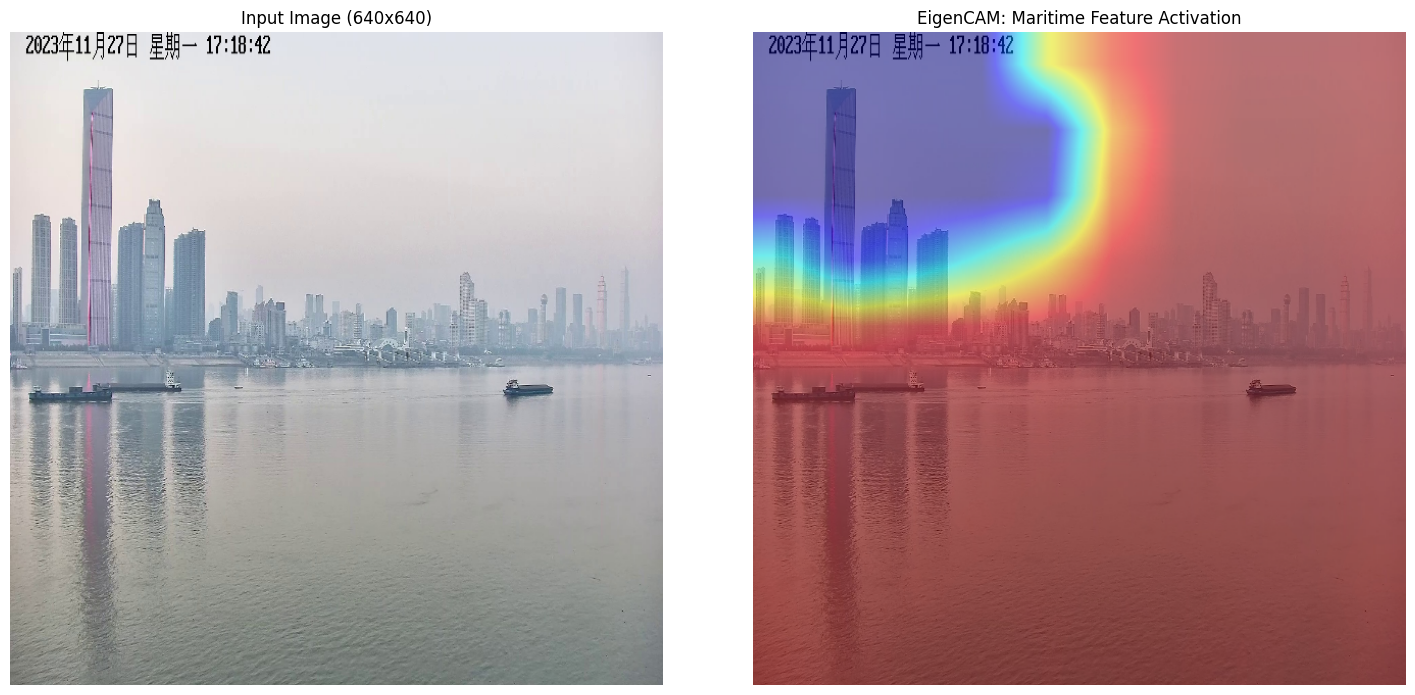

In [ ]:
# 1. Install necessary libraries
!pip install grad-cam opencv-python matplotlib -q

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from ultralytics import YOLO

# 2. Paths
model_path = '/content/runs/detect/yolov9c_fixed_v2/weights/best.pt'
img_path = '/content/yolov9/meiwvd_final_split/images/test/20231127_1659_3_113.jpg'

# 3. Load Model
model = YOLO(model_path)
model.model.eval()

# 4. Target Layer
# Layer 8 is the end of the YOLOv9 backbone
target_layers = [model.model.model[-2]]

# 5. Wrapper for Grad-CAM Compatibility
class Yolov9Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        # Return raw detections (first element of tuple)
        return self.model(x)[0]

wrapped_model = Yolov9Wrapper(model.model)

# 6. Initialize CAM
cam = EigenCAM(model=wrapped_model, target_layers=target_layers)

# 7. Preprocess Image (Fixing the size mismatch)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Resize to 640x640 to satisfy YOLO's stride requirements
img_resized = cv2.resize(img, (640, 640))
img_float = np.float32(img_resized) / 255.0

# Convert to tensor [B, C, H, W]
device = next(model.model.parameters()).device
input_tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0).to(device)

# 8. Generate CAM
grayscale_cam = cam(input_tensor=input_tensor)[0, :, :]
visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

# 9. Display
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Input Image (640x640)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("EigenCAM: Maritime Feature Activation")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
import gradio as gr
from PIL import Image

# --- 模型路径检测 ---
# 优先级：增强版权重 > Baseline权重 > 官方权重
paths = [
    '/content/best.pt',
    'yolov9c.pt'
]
default_model_path = next((p for p in paths if os.path.exists(p) or p.endswith('.pt') and '/' not in p), 'yolov9c.pt')

def predict_image(img, model_path, conf_threshold, iou_threshold):
    """更稳健的模型推理函数"""
    if img is None:
        return None

    try:
        # 加载模型
        model = YOLO(model_path)

        # 推理
        results = model.predict(
            source=img,
            conf=conf_threshold,
            iou=iou_threshold,
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )

        # 渲染结果
        res_plotted = results[0].plot()

        # 确保返回 RGB 格式给 Gradio
        if isinstance(res_plotted, np.ndarray):
            return cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        return None

    except Exception as e:
        print(f"Inference Error: {e}")
        return None

# --- 定义 Gradio 界面 ---
with gr.Blocks(title="MEIWVD 船只检测系统") as demo:
    gr.Markdown("# 🚢 MEIWVD 船只检测")
    gr.Markdown("如果页面显示 'No interface'，请点击下方的 **Public URL** 链接在新窗口打开。")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="上传待检测图片")
            model_input = gr.Textbox(value=default_model_path, label="模型权重路径 (best.pt)")

            with gr.Accordion("高级参数设置", open=False):
                conf_slider = gr.Slider(minimum=0.0, maximum=1.0, value=0.25, label="置信度 (Confidence)")
                iou_slider = gr.Slider(minimum=0.0, maximum=1.0, value=0.45, label="IOU 阈值")

            btn = gr.Button("✨ 开始检测", variant="primary")

        with gr.Column():
            output_img = gr.Image(type="numpy", label="检测结果可视化")

    btn.click(
        fn=predict_image,
        inputs=[input_img, model_input, conf_slider, iou_slider],
        outputs=output_img
    )

# --- 启动服务 ---
demo.launch(
    share=True,
    debug=False,
    inline=False,
    show_error=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c01875653e433d19ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install ultralytics streamlit pyngrok python-dotenv
# 安装 localtunnel 用于内网穿透
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 156.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 158.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 1s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
%%writefile app.py
import os
import cv2
import torch
import numpy as np
import streamlit as st
from ultralytics import YOLO
from PIL import Image

# --- 页面配置 ---
st.set_page_config(page_title="Colab YOLOv9 检测", layout="wide")

# --- 模型路径逻辑 ---
# 注意：在 Colab 中，确保你的权重文件路径是正确的
paths = [
    '/content/best.pt', # 假设你上传到了根目录
    'yolov9c.pt'        # 备选官方模型
]
default_model_path = next((p for p in paths if os.path.exists(p) or (p.endswith('.pt') and '/' not in p)), 'yolov9c.pt')

@st.cache_resource
def get_model(model_path):
    return YOLO(model_path)

def predict_image(img_array, model_path, conf_threshold, iou_threshold):
    model = get_model(model_path)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    results = model.predict(source=img_array, conf=conf_threshold, iou=iou_threshold, device=device)
    res_plotted = results[0].plot()
    return cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

# --- UI 界面 ---
st.title("🚢 MEIWVD 船只检测 - Colab 云端版")

st.sidebar.header("🔧 配置项")
model_path = st.sidebar.text_input("模型路径", value=default_model_path)
conf_slider = st.sidebar.slider("置信度", 0.0, 1.0, 0.25)
iou_slider = st.sidebar.slider("IOU 阈值", 0.0, 1.0, 0.45)

uploaded_file = st.file_uploader("上传图片", type=["jpg", "jpeg", "png"])

if uploaded_file:
    img = Image.open(uploaded_file)
    col1, col2 = st.columns(2)
    with col1:
        st.image(img, caption="原图", use_container_width=True)

    with col2:
        if st.button("开始检测", use_container_width=True):
            res = predict_image(np.array(img), model_path, conf_slider, iou_slider)
            st.image(res, caption="检测结果", use_container_width=True)

Writing app.py


In [ ]:
# 1. 获取你的 IP 地址（复制输出的这个 IP，后面有用）
import urllib
print("你的密码/隧道 IP 是:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# 2. 启动 Streamlit 并通过 localtunnel 暴露端口
# & 符号表示后台运行
!streamlit run app.py & npx localtunnel --port 8501

你的密码/隧道 IP 是: 34.126.110.209
⠙⠹⠸⠼⠴

your url is: https://smooth-rabbits-admire.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.126.110.209:8501

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  Stopping...
^C
